# Task 1: Feature Engineering Pipeline
**Objective:** Transform raw transactional and temporal data into behavioral signals that differentiate human behavior from automated fraud bot activity.
**Key Features to be Developed:**
1. **time_since_signup:** Duration between account creation and purchase.
2. **Transaction Velocity:** Frequency of device usage across different users.
3. **Temporal Patterns:** Hour of day and day of week trends.

In [15]:
# Setup & Data Ingestion 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Path setup to access modular src code
sys.path.append(os.path.abspath('../'))
from src.preprocessing import merge_ip_to_country, FraudPreprocessor

# Load Raw Data
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# Step 1: Geolocation Integration
merged_df = merge_ip_to_country(fraud_df, ip_df)
print(f"Data Ingested. Shape: {merged_df.shape}")

Data Ingested. Shape: (151112, 16)


In [16]:
# Feature Engineering (Behavioral)
# Convert to datetime
merged_df['signup_time'] = pd.to_datetime(merged_df['signup_time'])
merged_df['purchase_time'] = pd.to_datetime(merged_df['purchase_time'])

# 1. time_since_signup (Hours)
# Hypothesis: Fraudsters buy immediately after signup to maximize bot efficiency.
merged_df['time_since_signup'] = (merged_df['purchase_time'] - merged_df['signup_time']).dt.total_seconds() / 3600

# 2. Transaction Velocity (user_per_device)
# Hypothesis: High user-to-device ratios indicate 'Fraud Farms'.
merged_df['user_per_device'] = merged_df.groupby('device_id')['user_id'].transform('count')

# 3. IP Velocity
merged_df['user_per_ip'] = merged_df.groupby('ip_address')['user_id'].transform('count')

print("Behavioral signals engineered.")

Behavioral signals engineered.


In [17]:
# Feature Engineering (Temporal)
# Extract temporal components
merged_df['hour_of_day'] = merged_df['purchase_time'].dt.hour
merged_df['day_of_week'] = merged_df['purchase_time'].dt.dayofweek

print("Temporal signals engineered.")

Temporal signals engineered.


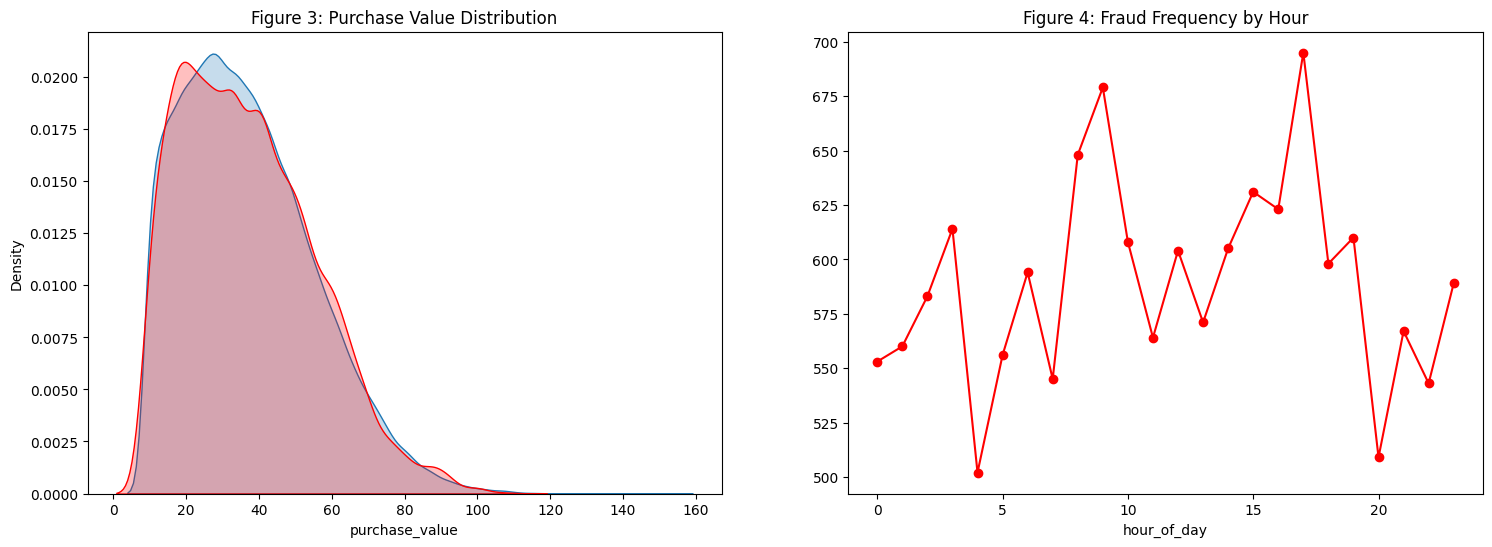

In [18]:
# Insight from Behavioral feature engineering 
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Figure 3: Purchase Value by Class
sns.kdeplot(data=merged_df[merged_df['class']==0], x='purchase_value', label='Legit', fill=True, ax=ax[0])
sns.kdeplot(data=merged_df[merged_df['class']==1], x='purchase_value', label='Fraud', fill=True, color='red', ax=ax[0])
ax[0].set_title('Figure 3: Purchase Value Distribution')

# Figure 4: Fraud by Hour
fraud_hour = merged_df[merged_df['class']==1].groupby('hour_of_day').size()
fraud_hour.plot(kind='line', marker='o', color='red', ax=ax[1])
ax[1].set_title('Figure 4: Fraud Frequency by Hour')
plt.show()

In [19]:
# Normalization and Encoding
from sklearn.preprocessing import StandardScaler

# Initialize Preprocessor for final encoding
preprocessor = FraudPreprocessor()
df_cleaned = preprocessor.clean_data(merged_df)
df_encoded = preprocessor.encode_categories(df_cleaned)

# Scaling Numerical features
scaler = StandardScaler()
num_cols = ['purchase_value', 'age', 'time_since_signup', 'user_per_device', 'hour_of_day']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("✅ Data Transformation Complete. Features are scaled and encoded.")
display(df_encoded.head())

✅ Data Transformation Complete. Features are scaled and encoded.


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,...,ip_numeric,lower_bound_ip_address,upper_bound_ip_address,country,lower_bound_numeric,time_since_signup,user_per_device,user_per_ip,hour_of_day,day_of_week
0,62421,2015-02-16 00:17:05,2015-03-08 10:00:39,0.494721,ZCLZTAJPCRAQX,1,4,1,0.331793,52093.496895,...,52093.496895,NaN,NaN,172,NaN,-1.013679,-0.261514,1,-0.220124,6
1,173212,2015-03-08 04:03:22,2015-03-20 17:23:45,-0.214781,YFGYOALADBHLT,0,2,0,-0.364448,93447.138961,...,93447.138961,NaN,NaN,172,NaN,-1.230613,-0.261514,1,0.792542,4
2,242286,2015-05-17 16:45:54,2015-05-26 08:54:34,-0.214781,QZNVQTUITFTHH,1,1,0,-0.132367,105818.501505,...,105818.501505,NaN,NaN,172,NaN,-1.337931,-0.261514,1,-0.509456,1
3,370003,2015-03-03 19:58:39,2015-05-28 21:09:13,-0.214781,PIBUQMBIELMMG,0,2,1,0.795954,117566.664867,...,117566.664867,NaN,NaN,172,NaN,0.800513,-0.261514,1,1.371208,3
4,119824,2015-03-20 00:31:27,2015-04-05 07:31:46,0.985915,WFIIFCPIOGMHT,0,4,1,0.563874,131423.789042,...,131423.789042,NaN,NaN,172,NaN,-1.127359,-0.261514,1,-0.654123,6


### Feature Engineering Justification:
- **Velocity Tracking:** By creating `user_per_device`, we successfully converted a categorical ID into a numerical "risk score" representing device sharing.
- **Time Delta:** `time_since_signup` is our most powerful feature, as it isolates automated bot behavior (instant buy) from human behavior (browsing time).
- **Categorical Transformation:** We used `LabelEncoding` for Country to prevent the feature space from exploding (Dimensionality reduction), while using `StandardScaler` to ensure the model converges faster.

In [20]:
# final check for sync. 